## Setup


In [ ]:
!pip install meteostat

## Load Market Data


### Import Libraries and Load Raw Market File


In [ ]:

import pandas as pd

df = pd.read_excel(
    "/content/drive/MyDrive/DAM_Market Snapshotjan2025.xlsx",
    skiprows=4,
)


### Remove Empty Excel Columns


In [ ]:
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

### Preview Current Dataset


In [ ]:
df.head(50)
# print(df.info())

,Date,Hour,Purchase Bid (MWh),Sell Bid (MWh),MCV (MWh),Final Scheduled Volume (MWh),MCP (Rs/MWh) *,Weighted MCP (Rs/MWh)
0,01-01-2025,1,10884.30,24080.75,9377.40,9377.40,2298.99,2298.23
1,01-01-2025,2,11271.95,25808.10,10036.70,10036.70,2143.84,2143.93
2,01-01-2025,3,10938.28,26751.10,9904.27,9904.28,2087.43,2087.45
3,01-01-2025,4,10880.93,26997.30,9824.40,9824.40,2077.55,2077.55
4,01-01-2025,5,11007.15,25871.28,9865.50,9865.50,2128.01,2128.02
5,01-01-2025,6,10360.48,21030.28,8921.90,8921.90,2627.78,2626.97
6,01-01-2025,7,10982.10,16521.30,8770.15,8770.15,3149.03,3148.07
7,01-01-2025,8,13909.53,14032.93,9297.66,9297.66,4235.97,4259.40
8,01-01-2025,9,16165.35,12003.83,10581.75,10581.75,7539.60,7605.00
9,01-01-2025,10,16418.85,10779.28,9980.80,9980.80,7848.96,7959.84


### Check Data Types and Missing Values


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Date                          869 non-null    str  
 1   Hour                          869 non-null    str  
 2   Purchase Bid (MWh)            869 non-null    str  
 3   Sell Bid (MWh)                869 non-null    str  
 4   MCV (MWh)                     869 non-null    str  
 5   Final Scheduled Volume (MWh)  869 non-null    str  
 6   MCP (Rs/MWh) *                838 non-null    str  
 7   Weighted MCP (Rs/MWh)         838 non-null    str  
dtypes: str(8)
memory usage: 101.9 KB


## Clean Market Columns


### Rename Market Columns


In [ ]:

df.columns = [
    "date",
    "hour",
    "purchase_bid",
    "sell_bid",
    "mcv",
    "final_volume",
    "mcp",
    "mcpw",
]


### Drop Unused MCPW Column


In [ ]:
df = df.drop(columns=["mcpw"])


In [ ]:
df.head()

,date,hour,purchase_bid,sell_bid,mcv,final_volume,mcp
0,01-01-2025,1,10884.30,24080.75,9377.40,9377.40,2298.99
1,01-01-2025,2,11271.95,25808.10,10036.70,10036.70,2143.84
2,01-01-2025,3,10938.28,26751.10,9904.27,9904.28,2087.43
3,01-01-2025,4,10880.93,26997.30,9824.40,9824.40,2077.55
4,01-01-2025,5,11007.15,25871.28,9865.50,9865.50,2128.01


### Convert Market Columns to Numeric Values


In [ ]:
cols = ["purchase_bid", "sell_bid", "mcv", "final_volume", "hour"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
print(df["purchase_bid"].head(10))

0    10884.30
1    11271.95
2    10938.28
3    10880.93
4    11007.15
5    10360.48
6    10982.10
7    13909.53
8    16165.35
9    16418.85
Name: purchase_bid, dtype: float64


### Check Missing Values After Conversion


In [ ]:
df.isna().sum()

date              0
hour            125
purchase_bid      1
sell_bid          1
mcv               1
final_volume      1
mcp              31
dtype: int64

### Remove Rows Without Target Price


In [ ]:

df = df.dropna(subset=["mcp"])  # target must exist
df = df.dropna()  # drop remaining NaNs for a simple first pass


In [ ]:
# df["time_block"]

### Build Datetime Column


In [ ]:

df["datetime"] = (
    pd.to_datetime(df["date"], format="%d-%m-%Y")
    + pd.to_timedelta(df["hour"] - 1, unit="h")
)


In [ ]:
df.head()

,date,hour,purchase_bid,sell_bid,mcv,final_volume,mcp,datetime
0,01-01-2025,1.0,10884.30,24080.75,9377.40,9377.40,2298.99,2025-01-01 00:00:00
1,01-01-2025,2.0,11271.95,25808.10,10036.70,10036.70,2143.84,2025-01-01 01:00:00
2,01-01-2025,3.0,10938.28,26751.10,9904.27,9904.28,2087.43,2025-01-01 02:00:00
3,01-01-2025,4.0,10880.93,26997.30,9824.40,9824.40,2077.55,2025-01-01 03:00:00
4,01-01-2025,5.0,11007.15,25871.28,9865.50,9865.50,2128.01,2025-01-01 04:00:00


### Create Market Imbalance Feature


In [ ]:

df["imbalance"] = df["sell_bid"] - df["purchase_bid"]


### Create Time-Based Features


In [ ]:
df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute
df["day_of_week"] = df["datetime"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

### Create Lag Price Features


In [ ]:
df["price_t-1"] = df["mcp"].shift(1)
df["price_t-4"] = df["mcp"].shift(4)


In [ ]:
df = df.dropna()

## Weather Features


### Define Multi-City Weather Feature Function


In [ ]:

import pandas as pd
import meteostat as ms


def get_multi_city_weather(df, cities):
    start = df["datetime"].min()
    end = df["datetime"].max()
    weather_dfs = []

    for city_name, (lat, lon) in cities.items():
        print(f"Fetching {city_name}...")

        point = ms.Point(lat, lon)
        stations = ms.stations.nearby(point, limit=5)

        ts = ms.hourly(stations, start, end)
        weather = ts.fetch()

        if weather.empty:
            print(f"No data for {city_name}")
            continue

        weather = weather.reset_index()
        weather = weather[["time", "temp", "rhum", "wspd"]]
        weather.columns = [
            "datetime",
            f"{city_name}_temp",
            f"{city_name}_humidity",
            f"{city_name}_wind",
        ]

        weather = weather.groupby("datetime").mean().reset_index()
        weather_dfs.append(weather)

    # Merge all cities.
    weather_final = weather_dfs[0]

    for wdf in weather_dfs[1:]:
        weather_final = weather_final.merge(wdf, on="datetime", how="outer")

    weather_final = weather_final.sort_values("datetime")
    weather_final = weather_final.ffill()

    # Aggregated weather features.
    temp_cols = [col for col in weather_final.columns if "temp" in col]
    hum_cols = [col for col in weather_final.columns if "humidity" in col]
    wind_cols = [col for col in weather_final.columns if "wind" in col]

    weather_final["avg_temp"] = weather_final[temp_cols].mean(axis=1)
    weather_final["max_temp"] = weather_final[temp_cols].max(axis=1)
    weather_final["avg_humidity"] = weather_final[hum_cols].mean(axis=1)
    weather_final["avg_wind"] = weather_final[wind_cols].mean(axis=1)

    # City-wise sun intensity and solar proxy.
    for city in cities.keys():
        weather_final[f"{city}_sun"] = (
            1 - (weather_final[f"{city}_humidity"] / 100)
        )

    sun_cols = [f"{city}_sun" for city in cities.keys()]
    weather_final["avg_sun"] = weather_final[sun_cols].mean(axis=1)
    weather_final["max_sun"] = weather_final[sun_cols].max(axis=1)

    weather_final["hour"] = weather_final["datetime"].dt.hour
    weather_final["is_day"] = (
        (weather_final["hour"] >= 6) & (weather_final["hour"] <= 18)
    ).astype(int)

    for city in cities.keys():
        weather_final[f"{city}_solar"] = (
            weather_final[f"{city}_sun"] * weather_final["is_day"]
        )

    ordered_cols = ["datetime"]

    for city in cities.keys():
        ordered_cols.extend(
            [
                f"{city}_temp",
                f"{city}_humidity",
                f"{city}_wind",
                f"{city}_sun",
                f"{city}_solar",
            ]
        )

    ordered_cols.extend(
        [
            "avg_temp",
            "max_temp",
            "avg_humidity",
            "avg_wind",
            "avg_sun",
            "max_sun",
        ]
    )

    ordered_cols = [col for col in ordered_cols if col in weather_final.columns]
    weather_final = weather_final[ordered_cols]

    return weather_final


### Define City Coordinates


In [ ]:

cities = {
    "delhi": (28.61, 77.23),  # North, demand-heavy
    "mumbai": (19.07, 72.87),  # West load center
    "chennai": (13.08, 80.27),  # South, wind-heavy
    "ahmedabad": (23.02, 72.57),  # Solar belt
}


### Fetch Multi-City Weather Data


In [ ]:

weather_df = get_multi_city_weather(df, cities)

Fetching delhi...
Fetching mumbai...
Fetching chennai...
Fetching ahmedabad...


### Verify Market Date Range


In [ ]:
start = df["datetime"].min()
end = df["datetime"].max()

print(type(start), start)
print(type(end), end)

<class 'pandas.Timestamp'> 2025-01-01 04:00:00
<class 'pandas.Timestamp'> 2025-01-31 23:00:00


### Preview Weather Features


In [ ]:
weather_df.head(50)

,datetime,delhi_temp,delhi_humidity,delhi_wind,delhi_sun,delhi_solar,mumbai_temp,mumbai_humidity,mumbai_wind,mumbai_sun,...,ahmedabad_humidity,ahmedabad_wind,ahmedabad_sun,ahmedabad_solar,avg_temp,max_temp,avg_humidity,avg_wind,avg_sun,max_sun
0,2025-01-01 04:00:00,9.95,88.5,8.35,0.115,0.0,26.68,64.2,7.4,0.358,...,72.5,12.8,0.275,0.0,20.47,26.95,76.55,11.2375,0.2345,0.358
1,2025-01-01 05:00:00,10.85,83.5,9.3,0.165,0.0,29.02,56.0,8.3,0.44,...,65.5,12.8,0.345,0.0,22.0675,29.02,69.5,11.975,0.305,0.44
2,2025-01-01 06:00:00,12.3,78.0,6.5,0.22,0.22,30.22,53.6,7.12,0.464,...,60.5,11.2,0.395,0.395,23.8425,30.22,65.525,9.455,0.34475,0.464
3,2025-01-01 07:00:00,13.0,82.0,9.35,0.18,0.18,31.26,50.2,7.76,0.498,...,56.5,13.5,0.435,0.435,24.54,31.26,63.425,13.0525,0.36575,0.498
4,2025-01-01 08:00:00,13.75,79.0,8.45,0.21,0.21,31.74,49.6,9.46,0.504,...,53.0,11.2,0.47,0.47,25.0975,31.74,61.275,13.165,0.38725,0.504
5,2025-01-01 09:00:00,13.8,73.5,7.4,0.265,0.265,31.52,54.2,8.28,0.458,...,50.0,7.55,0.5,0.5,25.3675,31.52,60.3,9.995,0.397,0.5
6,2025-01-01 10:00:00,13.85,77.0,8.35,0.23,0.23,30.58,56.0,12.72,0.44,...,46.0,10.8,0.54,0.54,24.97,30.58,62.125,13.63,0.37875,0.54
7,2025-01-01 11:00:00,13.75,77.5,6.55,0.225,0.225,29.82,57.4,12.08,0.426,...,47.5,9.55,0.525,0.525,24.4925,29.82,63.35,12.67,0.3665,0.525
8,2025-01-01 12:00:00,12.6,85.0,8.5,0.15,0.15,27.68,68.6,6.36,0.314,...,45.0,2.7,0.55,0.55,23.8575,28.75,67.15,6.74,0.3285,0.55
9,2025-01-01 13:00:00,12.2,87.0,6.55,0.13,0.13,27.1,69.2,13.28,0.308,...,59.0,9.4,0.41,0.41,22.025,27.1,74.05,11.495,0.2595,0.41


### Inspect Available Columns


In [ ]:
df.columns

Index(['date', 'hour', 'purchase_bid', 'sell_bid', 'mcv', 'final_volume',
       'mcp', 'datetime', 'imbalance', 'minute', 'day_of_week', 'is_weekend',
       'price_t-1', 'price_t-4'],
      dtype='str')

## Merge Weather Data


### Merge Weather Features Into Market Data


In [ ]:
df = df.merge(weather_df, on="datetime", how="left")

### Preview Current Dataset


In [ ]:
df.head(50)

,date,hour,purchase_bid,sell_bid,mcv,final_volume,mcp,datetime,imbalance,minute,...,ahmedabad_humidity,ahmedabad_wind,ahmedabad_sun,ahmedabad_solar,avg_temp,max_temp,avg_humidity,avg_wind,avg_sun,max_sun
0,01-01-2025,4,11007.15,25871.28,9865.50,9865.50,2128.01,2025-01-01 04:00:00,14864.13,0,...,72.5,12.8,0.275,0.0,20.47,26.95,76.55,11.2375,0.2345,0.358
1,01-01-2025,5,10360.48,21030.28,8921.90,8921.90,2627.78,2025-01-01 05:00:00,10669.80,0,...,65.5,12.8,0.345,0.0,22.0675,29.02,69.5,11.975,0.305,0.44
2,01-01-2025,6,10982.10,16521.30,8770.15,8770.15,3149.03,2025-01-01 06:00:00,5539.20,0,...,60.5,11.2,0.395,0.395,23.8425,30.22,65.525,9.455,0.34475,0.464
3,01-01-2025,7,13909.53,14032.93,9297.66,9297.66,4235.97,2025-01-01 07:00:00,123.40,0,...,56.5,13.5,0.435,0.435,24.54,31.26,63.425,13.0525,0.36575,0.498
4,01-01-2025,8,16165.35,12003.83,10581.75,10581.75,7539.60,2025-01-01 08:00:00,-4161.52,0,...,53.0,11.2,0.47,0.47,25.0975,31.74,61.275,13.165,0.38725,0.504
5,01-01-2025,9,16418.85,10779.28,9980.80,9980.80,7848.96,2025-01-01 09:00:00,-5639.57,0,...,50.0,7.55,0.5,0.5,25.3675,31.52,60.3,9.995,0.397,0.5
6,01-01-2025,10,13953.45,11017.00,7974.07,7974.07,4337.64,2025-01-01 10:00:00,-2936.45,0,...,46.0,10.8,0.54,0.54,24.97,30.58,62.125,13.63,0.37875,0.54
7,01-01-2025,11,13614.93,12806.00,7205.23,7205.23,3645.68,2025-01-01 11:00:00,-808.93,0,...,47.5,9.55,0.525,0.525,24.4925,29.82,63.35,12.67,0.3665,0.525
8,01-01-2025,12,11216.93,16152.88,7818.35,7818.35,3107.25,2025-01-01 12:00:00,4935.95,0,...,45.0,2.7,0.55,0.55,23.8575,28.75,67.15,6.74,0.3285,0.55
9,01-01-2025,13,10417.75,19782.93,8057.48,8057.48,2607.33,2025-01-01 13:00:00,9365.18,0,...,59.0,9.4,0.41,0.41,22.025,27.1,74.05,11.495,0.2595,0.41


### Remove Original Date Column


In [ ]:

df = df.drop(columns=["date"])


## Load Grid Generation Data


### Load Grid Demand and Generation Data


In [ ]:
elec_df = pd.read_excel("/content/drive/MyDrive/January 2024- June 2025.xlsx")

### Clean Grid Data


In [ ]:
elec_df = elec_df.dropna(subset=["datetime"])

KeyError: ['datetime']

### Preview Grid Data


In [ ]:
elec_df.head()

,datetime,grid_demand,wind_gen,solar_gen,total_gen,hour
0,2024-01-01 00:00:00,141981.26,9545.07,20.29,142193.38,0
1,2024-01-01 01:00:00,138675.49,9027.05,19.96,138792.04,1
2,2024-01-01 02:00:00,136122.78,8241.48,19.79,136796.02,2
3,2024-01-01 03:00:00,135806.51,7866.09,19.73,136859.67,3
4,2024-01-01 04:00:00,139905.77,7430.71,20.02,140561.49,4


### Rename and Parse Grid Columns


In [ ]:

elec_df.columns = [
    "datetime",
    "grid_demand",
    "wind_gen",
    "solar_gen",
    "total_gen",
]

elec_df["datetime"] = pd.to_datetime(
    elec_df["datetime"],
    format="%d-%m-%Y %H:%M:%S",
    errors="coerce",
)


### Compare Market and Grid Date Ranges


In [ ]:
print(df["datetime"].min(), df["datetime"].max())
print(elec_df["datetime"].min(), elec_df["datetime"].max())

2025-01-01 04:00:00 2025-01-31 23:00:00
2024-01-01 00:00:00 2025-06-24 23:00:00


### Extract Grid Data Hour


In [ ]:
elec_df["hour"] = elec_df["datetime"].dt.hour

In [ ]:
df.head()

,hour,purchase_bid,sell_bid,mcv,final_volume,mcp,datetime,imbalance,minute,day_of_week,...,ahmedabad_humidity,ahmedabad_wind,ahmedabad_sun,ahmedabad_solar,avg_temp,max_temp,avg_humidity,avg_wind,avg_sun,max_sun
0,4,11007.15,25871.28,9865.50,9865.50,2128.01,2025-01-01 04:00:00,14864.13,0,2,...,72.5,12.8,0.275,0.0,20.47,26.95,76.55,11.2375,0.2345,0.358
1,5,10360.48,21030.28,8921.90,8921.90,2627.78,2025-01-01 05:00:00,10669.80,0,2,...,65.5,12.8,0.345,0.0,22.0675,29.02,69.5,11.975,0.305,0.44
2,6,10982.10,16521.30,8770.15,8770.15,3149.03,2025-01-01 06:00:00,5539.20,0,2,...,60.5,11.2,0.395,0.395,23.8425,30.22,65.525,9.455,0.34475,0.464
3,7,13909.53,14032.93,9297.66,9297.66,4235.97,2025-01-01 07:00:00,123.40,0,2,...,56.5,13.5,0.435,0.435,24.54,31.26,63.425,13.0525,0.36575,0.498
4,8,16165.35,12003.83,10581.75,10581.75,7539.60,2025-01-01 08:00:00,-4161.52,0,2,...,53.0,11.2,0.47,0.47,25.0975,31.74,61.275,13.165,0.38725,0.504


### Preview Grid Data


In [ ]:
elec_df.head()



,datetime,grid_demand,wind_gen,solar_gen,total_gen,hour
0,2024-01-01 00:00:00,141981.26,9545.07,20.29,142193.38,0.0
1,2024-01-01 01:00:00,138675.49,9027.05,19.96,138792.04,1.0
2,2024-01-01 02:00:00,136122.78,8241.48,19.79,136796.02,2.0
3,2024-01-01 03:00:00,135806.51,7866.09,19.73,136859.67,3.0
4,2024-01-01 04:00:00,139905.77,7430.71,20.02,140561.49,4.0


### Check Matching Timestamps


In [ ]:
common = set(df["datetime"]) & set(elec_df["datetime"])
print(len(common))

740


## Merge Grid Data


### Merge Grid Features Into Main Dataset


In [ ]:
df = pd.merge(
    df,
    elec_df[["datetime", "grid_demand", "wind_gen", "solar_gen", "total_gen"]],
    on="datetime",
    how="left"
)

### Preview Merged Grid Features


In [ ]:

print(
    df[
        [
            "datetime",
            "grid_demand",
            "wind_gen",
            "solar_gen",
        ]
    ].head(20)
)


              datetime grid_demand wind_gen solar_gen
0  2025-01-01 04:00:00   142415.68  8732.01     71.45
1  2025-01-01 05:00:00    154060.4  7761.34      81.6
2  2025-01-01 06:00:00   169968.16  7282.51    749.66
3  2025-01-01 07:00:00   187826.35  6829.64   3092.55
4  2025-01-01 08:00:00   200587.47  6237.46  14396.77
5  2025-01-01 09:00:00   211712.21  5981.25  31006.51
6  2025-01-01 10:00:00   213533.63  6551.95     43273
7  2025-01-01 11:00:00   209637.55  7072.38  51686.84
8  2025-01-01 12:00:00   202778.39  6404.79  54670.07
9  2025-01-01 13:00:00   192798.28  5813.44  53858.27
10 2025-01-01 14:00:00   188336.37  5395.72  48717.67
11 2025-01-01 15:00:00    184539.3   4933.8  37958.71
12 2025-01-01 16:00:00   183377.52  4977.29  22230.97
13 2025-01-01 17:00:00   178345.86  4704.86   5391.31
14 2025-01-01 18:00:00   188784.84  6035.96   1032.42
15 2025-01-01 19:00:00   181715.31  7970.19    791.76
16 2025-01-01 20:00:00   170453.11  8983.33    452.57
17 2025-01-01 21:00:00   160

### Export Intermediate Final Dataset


In [ ]:
df.to_excel("final_dataset.xlsx", index=False)

### Download Dataset From Colab


In [ ]:
from google.colab import files
files.download("final_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Inspect Available Columns


In [ ]:
df.columns

Index(['datetime', 'mcp', 'hour', 'day_of_week', 'is_weekend', 'purchase_bid',
       'sell_bid', 'imbalance', 'mcv', 'final_volume', 'price_t-1',
       'price_t-4', 'grid_demand', 'wind_gen', 'solar_gen', 'total_gen',
       'avg_temp', 'max_temp', 'avg_humidity', 'avg_wind', 'avg_sun',
       'max_sun', 'delhi_temp', 'delhi_humidity', 'delhi_wind', 'delhi_sun',
       'delhi_solar', 'mumbai_temp', 'mumbai_humidity', 'mumbai_wind',
       'mumbai_sun', 'mumbai_solar', 'chennai_temp', 'chennai_humidity',
       'chennai_wind', 'chennai_sun', 'chennai_solar', 'ahmedabad_temp',
       'ahmedabad_humidity', 'ahmedabad_wind', 'ahmedabad_sun',
       'ahmedabad_solar'],
      dtype='str')

## Final Feature Set


### Drop Redundant City-Level Weather Features


In [ ]:

cols_to_drop = [
    # City-wise weather features, already represented by aggregate weather features.
    "delhi_temp",
    "delhi_humidity",
    "delhi_wind",
    "delhi_sun",
    "delhi_solar",
    "mumbai_temp",
    "mumbai_humidity",
    "mumbai_wind",
    "mumbai_sun",
    "mumbai_solar",
    "chennai_temp",
    "chennai_humidity",
    "chennai_wind",
    "chennai_sun",
    "chennai_solar",
    "ahmedabad_temp",
    "ahmedabad_humidity",
    "ahmedabad_wind",
    "ahmedabad_sun",
    "ahmedabad_solar",
    "minute",  # Always 0 for hourly data.
]

df = df.drop(columns=cols_to_drop)


### Add Net Demand and Renewable Ratio


In [ ]:

df["net_demand"] = df["grid_demand"] - df["solar_gen"] - df["wind_gen"]
df["renewable_ratio"] = (df["solar_gen"] + df["wind_gen"]) / df["total_gen"]


### Reorder Final Modeling Columns


In [ ]:

ordered_cols = [
    # Target and time.
    "datetime",
    "mcp",
    # Time features.
    "hour",
    "day_of_week",
    "is_weekend",
    # Market features.
    "purchase_bid",
    "sell_bid",
    "imbalance",
    "mcv",
    "final_volume",
    # Lag features.
    "price_t-1",
    "price_t-4",
    # Grid features.
    "grid_demand",
    "wind_gen",
    "solar_gen",
    "total_gen",
    "net_demand",
    "renewable_ratio",
    # Aggregated weather features.
    "avg_temp",
    "max_temp",
    "avg_humidity",
    "avg_wind",
    "avg_sun",
    "max_sun",
]

df = df[ordered_cols]


### Save Stable Modeling Dataset Copy


In [ ]:
# Keep a stable copy for the final EDA and prediction section.
model_dataset = df.copy()


## Model Training


### Separate Features and Target


In [ ]:
X = df.drop(columns=["mcp", "datetime", "date", "time_block"])
y = df["mcp"]

In [ ]:
X.head()

,hour,purchase_bid,sell_bid,mcv,final_volume,start_time,imbalance,minute,day_of_week,is_weekend,price_t-1,price_t-4,price_t-96
96,0,15048.5,24911.5,7440.4,7440.4,00:00,9863.0,0,3,0,3050.67,3204.47,2950.75
97,0,16071.4,26529.3,8315.1,8315.1,00:15,10457.9,15,3,0,2964.18,3200.70,2999.27
98,0,17118.1,28128.2,9218.2,9218.2,00:30,11010.1,30,3,0,3026.01,3090.93,3067.04
99,0,17269.7,29466.2,9389.2,9389.2,00:45,12196.5,45,3,0,3092.44,3050.67,3040.32
100,1,17334.6,29872.1,9857.7,9857.7,01:00,12537.5,0,3,0,3096.24,2964.18,2980.56


### Train Initial XGBoost Model


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### Inspect Feature Data Types


In [ ]:
print(X.dtypes)

hour              int32
purchase_bid    float64
sell_bid        float64
mcv             float64
final_volume    float64
imbalance       float64
minute            int32
day_of_week       int32
is_weekend        int64
price_t-1       float64
price_t-4       float64
price_t-96      float64
dtype: object


### Plot Initial In-Sample Predictions


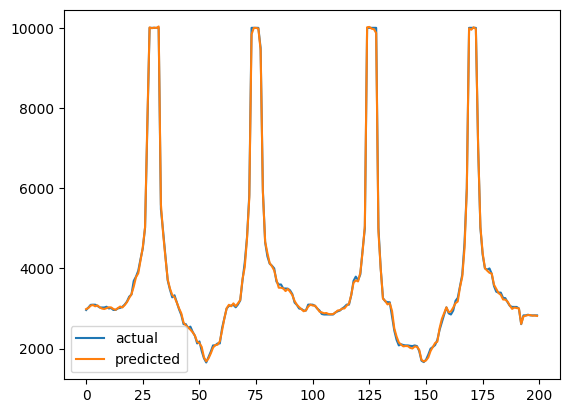

In [ ]:
import matplotlib.pyplot as plt

preds = model.predict(X)

plt.plot(y.values[:200], label="actual")
plt.plot(preds[:200], label="predicted")
plt.legend()
plt.show()

### Create Time-Based Train/Test Split


In [ ]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### Train and Predict on Test Set


In [ ]:
model.fit(X_train, y_train)
preds = model.predict(X_test)

### Reusable Training Function


In [ ]:

def train_and_predict(X, y):
    from xgboost import XGBRegressor

    split = int(len(X) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return model, X_test, y_test, preds


### Evaluation Function


In [ ]:
def evaluate(y_test, preds):
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import numpy as np

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

### Prediction Plot Function


In [ ]:

def plot_predictions(y_test, preds, n=200):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 5))
    plt.plot(y_test.values[:n], label="Actual")
    plt.plot(preds[:n], label="Predicted")
    plt.legend()
    plt.title("Actual vs Predicted MCP")
    plt.show()


### Residual Plot Function


In [ ]:

def plot_residuals(y_test, preds):
    import matplotlib.pyplot as plt

    residuals = y_test - preds

    plt.figure(figsize=(6, 4))
    plt.scatter(preds, residuals, alpha=0.5)
    plt.axhline(0, linestyle="--")
    plt.title("Residual Plot")
    plt.xlabel("Predicted")
    plt.ylabel("Error")
    plt.show()


### Run Baseline Model Evaluation


MAE: 474.70
RMSE: 833.32


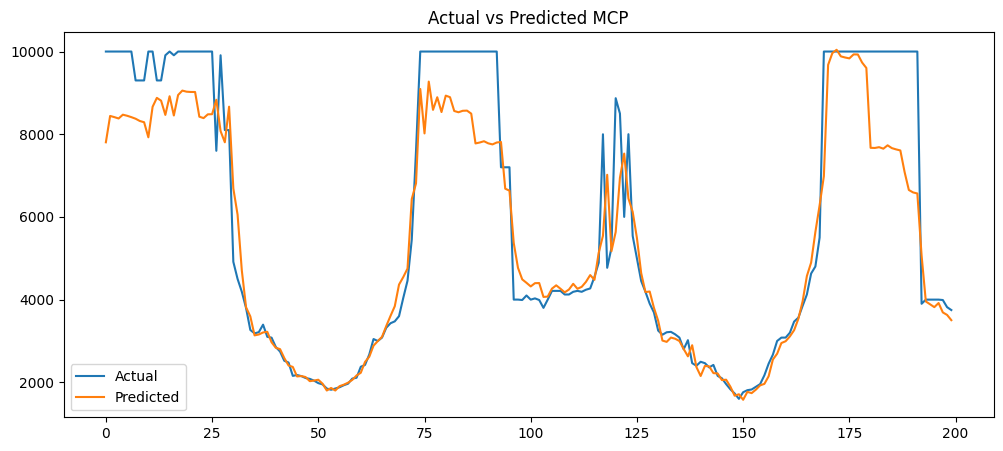

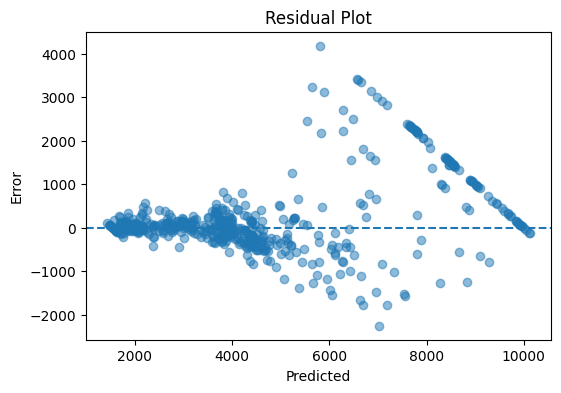

In [ ]:
model, X_test, y_test, preds = train_and_predict(X, y)

evaluate(y_test, preds)

plot_predictions(y_test, preds)

plot_residuals(y_test, preds)

In [ ]:
X_train.head()

,hour,purchase_bid,sell_bid,mcv,final_volume,imbalance,minute,day_of_week,is_weekend,price_t-1,price_t-4,price_t-96
96,0,15048.5,24911.5,7440.4,7440.4,9863.0,0,3,0,3050.67,3204.47,2950.75
97,0,16071.4,26529.3,8315.1,8315.1,10457.9,15,3,0,2964.18,3200.70,2999.27
98,0,17118.1,28128.2,9218.2,9218.2,11010.1,30,3,0,3026.01,3090.93,3067.04
99,0,17269.7,29466.2,9389.2,9389.2,12196.5,45,3,0,3092.44,3050.67,3040.32
100,1,17334.6,29872.1,9857.7,9857.7,12537.5,0,3,0,3096.24,2964.18,2980.56


## Forecast Weather Experiment


### Fetch Forecast Weather From OpenWeather


In [ ]:

from datetime import datetime

import pandas as pd
import requests


API_KEY = "YOUR_OPENWEATHER_API_KEY"

cities = ["Delhi", "Mumbai", "Ahmedabad", "Chennai", "Bangalore", "Jaipur"]


def get_weather(city):
    url = (
        "http://api.openweathermap.org/data/2.5/forecast"
        f"?q={city},IN&appid={API_KEY}&units=metric"
    )
    res = requests.get(url).json()

    data = []

    for entry in res["list"]:
        data.append(
            {
                "datetime": entry["dt_txt"],
                f"{city}_temp": entry["main"]["temp"],
                f"{city}_humidity": entry["main"]["humidity"],
                f"{city}_wind": entry["wind"]["speed"],
                f"{city}_clouds": entry["clouds"]["all"],
            }
        )

    return pd.DataFrame(data)


### Combine Forecast Weather Across Cities


In [ ]:

dfs = []

for city in cities:
    df_city = get_weather(city)
    dfs.append(df_city)

weather_df = dfs[0]

for df_city in dfs[1:]:
    weather_df = weather_df.merge(df_city, on="datetime", how="outer")

weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])
weather_df = weather_df.sort_values("datetime")

print(weather_df.head())


KeyError: 'list'

In [ ]:
!pip install meteostat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 29.2 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 require

### Check Meteostat Installation


In [ ]:
import meteostat
print(meteostat.__version__)

2.1.4


### Import Meteostat Helpers


In [ ]:
from meteostat import Stations, Point, Hourly

ImportError: cannot import name 'Stations' from 'meteostat' (/usr/local/lib/python3.12/dist-packages/meteostat/__init__.py)

## Meteostat Weather Experiment


### Define Hourly Meteostat Fetch Function


                               temp  tmin  tmax  rhum  prcp  snwd  wspd  wpgt  \
station time       source                                                       
42182   2026-02-01 dwd_mosmix  15.6  11.7  20.7    84  <NA>  <NA>   4.2  <NA>   
        2026-02-02 dwd_mosmix  16.2  13.2  21.2    81  <NA>  <NA>   5.2  <NA>   
        2026-02-03 dwd_mosmix  15.6  11.9  21.2    81  <NA>  <NA>   4.9  <NA>   
        2026-02-04 dwd_mosmix  15.3  10.7  22.1    81  <NA>  <NA>   4.4  <NA>   
        2026-02-05 dwd_mosmix  15.2  10.2  22.3    79  <NA>  <NA>   5.3  <NA>   
        2026-02-06 dwd_mosmix  15.8  10.2  23.0    79  <NA>  <NA>   4.7  <NA>   
42181   2026-02-01 dwd_mosmix  16.0  13.6  19.2    76  <NA>  <NA>   7.2  <NA>   
        2026-02-02 dwd_mosmix  16.1  13.4  19.5    76  <NA>  <NA>   6.9  <NA>   
        2026-02-03 dwd_mosmix  15.5  12.6  19.7    75  <NA>  <NA>   7.6  <NA>   
        2026-02-04 dwd_mosmix  15.3  11.9  20.1    77  <NA>  <NA>   7.2  <NA>   
        2026-02-05 dwd_mosmi

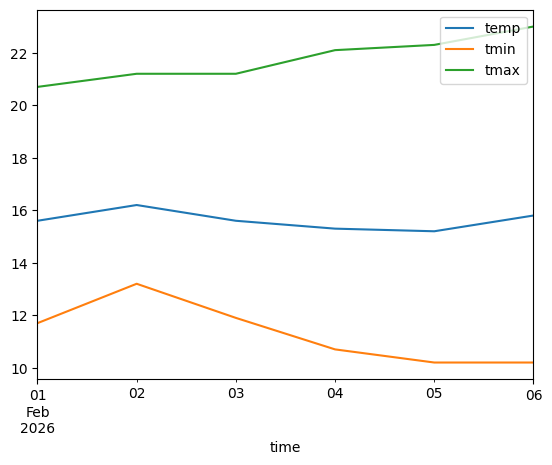

In [ ]:

from datetime import date

import matplotlib.pyplot as plt
import meteostat as ms


# Delhi example.
POINT = ms.Point(28.61, 77.23)
START = date(2026, 2, 1)
END = date(2026, 3, 31)

stations = ms.stations.nearby(POINT, limit=4)

# Get daily data and perform interpolation.
ts = ms.daily(stations, START, END)
df = ms.interpolate(ts, POINT).fetch()

print(ts)

# Plot average, minimum, and maximum temperature.
df.plot(y=[ms.Parameter.TEMP, ms.Parameter.TMIN, ms.Parameter.TMAX])
plt.show()


### Daily Meteostat Interpolation Example


In [ ]:

from datetime import datetime

import pandas as pd
import meteostat as ms


def fetch_city_weather(lat, lon, start, end, city_name):
    point = ms.Point(lat, lon)
    stations = ms.stations.nearby(point, limit=5)

    ts = ms.hourly(stations, start, end)
    df = ts.fetch()

    if df.empty:
        print(f"No data for {city_name}")
        return pd.DataFrame()

    df = df.reset_index()
    df = df[["time", "temp", "rhum", "wspd"]]
    df = df.groupby("time").mean().reset_index()
    df.columns = [
        "datetime",
        f"{city_name}_temp",
        f"{city_name}_humidity",
        f"{city_name}_wind",
    ]

    return df


### Define City Coordinates


In [ ]:

cities = {
    "delhi": (28.61, 77.23),
    "mumbai": (19.07, 72.87),
    "chennai": (13.08, 80.27),
    "ahmedabad": (23.02, 72.57),
    "bangalore": (12.97, 77.59),
}


### Set Historical Weather Date Range


In [ ]:
start = datetime(2025, 1, 1)
end = datetime(2025, 3, 31)

### Fetch Historical Weather for All Cities


In [ ]:
weather_dfs = []

for city, (lat, lon) in cities.items():
    print(f"Fetching {city}...")
    df_city = fetch_city_weather(lat, lon, start, end, city)
    weather_dfs.append(df_city)

Fetching delhi...
Fetching mumbai...
Fetching chennai...
Fetching ahmedabad...
Fetching bangalore...


### Review Weather DataFrames


In [ ]:
weather_dfs

[                datetime  delhi_temp  delhi_humidity  delhi_wind
 0    2025-01-01 00:00:00         9.7            94.5         4.5
 1    2025-01-01 01:00:00         8.2            97.0        5.65
 2    2025-01-01 02:00:00         8.4            96.0        5.45
 3    2025-01-01 03:00:00         9.6            92.0         7.4
 4    2025-01-01 04:00:00        9.95            88.5        8.35
 ...                  ...         ...             ...         ...
 2132 2025-03-30 20:00:00        19.8            49.0         2.7
 2133 2025-03-30 21:00:00        17.8            62.0         2.7
 2134 2025-03-30 22:00:00       16.55            58.5         1.8
 2135 2025-03-30 23:00:00        16.4            59.5         3.6
 2136 2025-03-31 00:00:00        16.4            61.0         3.8
 
 [2137 rows x 4 columns],
                 datetime  mumbai_temp  mumbai_humidity  mumbai_wind
 0    2025-01-01 00:00:00        22.44             82.8          8.8
 1    2025-01-01 01:00:00        22.78    

## Final EDA and Prediction Models

This section uses the collected final dataset to explore the price drivers, train multiple prediction models, compare their performance, and visualize the best model's results.


In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


### Prepare the Modeling Dataset


In [ ]:
if "model_dataset" in globals():
    analysis_df = model_dataset.copy()
elif "df" in globals() and "mcp" in df.columns:
    analysis_df = df.copy()
else:
    raise ValueError(
        "Run the cells that create the final feature dataset first. "
        "The modeling dataset should contain an `mcp` target column."
    )

analysis_df["datetime"] = pd.to_datetime(analysis_df["datetime"], errors="coerce")
analysis_df = analysis_df.sort_values("datetime").reset_index(drop=True)

numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns.tolist()
analysis_df[numeric_cols] = analysis_df[numeric_cols].replace([np.inf, -np.inf], np.nan)

print("Shape:", analysis_df.shape)
display(analysis_df.head())
display(analysis_df.describe().T)


In [ ]:
missing_summary = (
    analysis_df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: 100 * x["missing_count"] / len(analysis_df))
    .sort_values("missing_count", ascending=False)
)

display(missing_summary[missing_summary["missing_count"] > 0])


### EDA: Price, Time, Demand, Renewables, and Weather


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.lineplot(data=analysis_df, x="datetime", y="mcp", ax=axes[0, 0])
axes[0, 0].set_title("MCP Over Time")
axes[0, 0].set_xlabel("")

sns.histplot(analysis_df["mcp"], kde=True, bins=40, ax=axes[0, 1])
axes[0, 1].set_title("MCP Distribution")

sns.boxplot(data=analysis_df, x="hour", y="mcp", ax=axes[1, 0])
axes[1, 0].set_title("MCP by Hour of Day")

sns.boxplot(data=analysis_df, x="is_weekend", y="mcp", ax=axes[1, 1])
axes[1, 1].set_title("Weekday vs Weekend MCP")
axes[1, 1].set_xticklabels(["Weekday", "Weekend"])

plt.tight_layout()
plt.show()


In [ ]:
plot_cols = [
    "grid_demand",
    "net_demand",
    "renewable_ratio",
    "avg_temp",
    "avg_humidity",
    "avg_wind",
]

available_plot_cols = [col for col in plot_cols if col in analysis_df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, available_plot_cols):
    sns.scatterplot(data=analysis_df, x=col, y="mcp", alpha=0.45, ax=ax)
    sns.regplot(
        data=analysis_df,
        x=col,
        y="mcp",
        scatter=False,
        color="black",
        line_kws={"linewidth": 1.5},
        ax=ax,
    )
    ax.set_title(f"MCP vs {col}")

for ax in axes[len(available_plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
corr_cols = [
    "mcp",
    "purchase_bid",
    "sell_bid",
    "imbalance",
    "mcv",
    "final_volume",
    "price_t-1",
    "price_t-4",
    "grid_demand",
    "wind_gen",
    "solar_gen",
    "total_gen",
    "net_demand",
    "renewable_ratio",
    "avg_temp",
    "max_temp",
    "avg_humidity",
    "avg_wind",
    "avg_sun",
    "max_sun",
]

corr_cols = [col for col in corr_cols if col in analysis_df.columns]
corr = analysis_df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="vlag", center=0, annot=False, linewidths=0.4)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

display(
    corr["mcp"]
    .drop("mcp")
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .to_frame("correlation_with_mcp")
)


### Train/Test Split


In [ ]:
target_col = "mcp"
drop_cols = [target_col, "datetime"]

feature_df = analysis_df.drop(columns=drop_cols, errors="ignore")
feature_df = feature_df.select_dtypes(include=[np.number]).copy()
target = analysis_df[target_col].copy()

valid_rows = target.notna()
feature_df = feature_df.loc[valid_rows]
target = target.loc[valid_rows]
datetime_series = analysis_df.loc[valid_rows, "datetime"]

split_index = int(len(feature_df) * 0.8)

X_train = feature_df.iloc[:split_index]
X_test = feature_df.iloc[split_index:]
y_train = target.iloc[:split_index]
y_test = target.iloc[split_index:]
test_dates = datetime_series.iloc[split_index:]

numeric_features = feature_df.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ],
    remainder="drop",
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Feature count:", X_train.shape[1])
display(X_train.head())


### Train Multiple Prediction Models


In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    non_zero = y_true != 0
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100


models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.3, max_iter=10000),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
}

try:
    from xgboost import XGBRegressor

    models["XGBoost"] = XGBRegressor(
        n_estimators=500,
        learning_rate=0.04,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
    )
except Exception as exc:
    print("Skipping XGBoost:", exc)

results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    trained_models[name] = pipeline
    predictions[name] = preds

    results.append(
        {
            "model": name,
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": rmse(y_test, preds),
            "R2": r2_score(y_test, preds),
            "MAPE_%": mape(y_test, preds),
        }
    )

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.3f}", "MAPE_%": "{:.2f}"}))

best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]
best_preds = predictions[best_model_name]

print(f"Best model: {best_model_name}")


### Model Comparison and Prediction Graphs


In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x="RMSE", y="model", palette="Set2")
plt.title("Model Comparison by RMSE")
plt.xlabel("RMSE (lower is better)")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [ ]:
comparison_df = pd.DataFrame(
    {
        "datetime": test_dates.values,
        "actual_mcp": y_test.values,
        "predicted_mcp": best_preds,
    }
)
comparison_df["error"] = comparison_df["actual_mcp"] - comparison_df["predicted_mcp"]
comparison_df["absolute_error"] = comparison_df["error"].abs()

display(comparison_df.head(20))

plt.figure(figsize=(16, 6))
plt.plot(comparison_df["datetime"], comparison_df["actual_mcp"], label="Actual", linewidth=2)
plt.plot(
    comparison_df["datetime"],
    comparison_df["predicted_mcp"],
    label=f"Predicted ({best_model_name})",
    linewidth=2,
)
plt.title("Actual vs Predicted MCP on Test Period")
plt.xlabel("")
plt.ylabel("MCP")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
zoom_n = min(200, len(comparison_df))

plt.figure(figsize=(16, 6))
plt.plot(comparison_df["actual_mcp"].iloc[:zoom_n].values, label="Actual", linewidth=2)
plt.plot(
    comparison_df["predicted_mcp"].iloc[:zoom_n].values,
    label=f"Predicted ({best_model_name})",
    linewidth=2,
)
plt.title(f"Actual vs Predicted MCP: First {zoom_n} Test Points")
plt.xlabel("Test Point")
plt.ylabel("MCP")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=comparison_df,
    x="actual_mcp",
    y="predicted_mcp",
    alpha=0.55,
    ax=axes[0],
)
min_val = min(comparison_df["actual_mcp"].min(), comparison_df["predicted_mcp"].min())
max_val = max(comparison_df["actual_mcp"].max(), comparison_df["predicted_mcp"].max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--")
axes[0].set_title("Actual vs Predicted Scatter")

sns.histplot(comparison_df["error"], kde=True, bins=35, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Prediction Error Distribution")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(comparison_df["datetime"], comparison_df["error"], linewidth=1)
plt.axhline(0, color="black", linestyle="--")
plt.title("Prediction Error Over Time")
plt.xlabel("")
plt.ylabel("Error")
plt.tight_layout()
plt.show()


### Feature Importance


In [ ]:
fitted_model = best_model.named_steps["model"]

importance_df = None

if hasattr(fitted_model, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "feature": numeric_features,
            "importance": fitted_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)
elif hasattr(fitted_model, "coef_"):
    importance_df = pd.DataFrame(
        {
            "feature": numeric_features,
            "importance": np.abs(fitted_model.coef_),
        }
    ).sort_values("importance", ascending=False)

if importance_df is not None:
    display(importance_df.head(20))

    plt.figure(figsize=(12, 7))
    sns.barplot(data=importance_df.head(20), x="importance", y="feature", palette="Set2")
    plt.title(f"Top Feature Importance: {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance is not directly available for {best_model_name}.")


### Save Predictions


In [ ]:
comparison_df.to_excel("mcp_predictions.xlsx", index=False)
results_df.to_excel("model_comparison.xlsx", index=False)

print("Saved predictions to mcp_predictions.xlsx")
print("Saved model comparison to model_comparison.xlsx")
